In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [ ]:
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 01 — Data Cleaning
**Goal:** Clean raw LFS microdata for analysis\
**Input:** Raw LFS CSV from Statistics Canada\
**Output:** employment_clean.csv \
**Key steps:** dropping unwanted columns, column renaming,
filtering, type casting

In [ ]:
def load_employment(path: str = "/content/14100287.csv") -> pd.DataFrame:
    print("Loading dataset...")
    df = pd.read_csv(path)

    print(f"  Raw shape : {df.shape}")

    print("Dropping unwanted columns...")
    df = df.drop(columns=['STATUS','SYMBOL','TERMINATED','DGUID','DECIMALS','VECTOR','COORDINATE','UOM_ID','SCALAR_ID'])

    df['REF_DATE'] = pd.to_datetime(df["REF_DATE"], format="%Y-%m", errors="coerce")

    print("Renaming column names...")
    df.rename(columns={'REF_DATE':'date','GEO':'province','Labour force characteristics':'labour_characteristics','Gender':'gender','Age group':'age','Statistics':'statistics','Data type':'data_type','UOM':'unit_of_measurement','SCALAR_FACTOR':'scalar_factor','VALUE':'value'}, inplace=True)

    df = df[(df['date']>="2020-01") & (df['date']<="2025-12")]

    df['value'] = pd.to_numeric(df['value'], errors='coerce')

    df = df.dropna(subset=['value'])

    df = df[df['province']!='Canada']
    df = df[df['gender']!='Total - Gender']
    df = df[df['statistics']=='Estimate']
    df = df[df['data_type']=='Seasonally adjusted']

    print(f"\n  Clean shape : {df.shape}")
    print(f"  Provinces   : {df['province'].nunique()}")

    return df

In [ ]:
emp = load_employment()

Loading dataset...


/tmp/ipykernel_10464/2018693625.py:3: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


  Raw shape : (5412582, 19)
Dropping unwanted columns...
Renaming column names...

  Clean shape : (74880, 10)
  Provinces   : 10


In [ ]:
emp.head()

,date,province,labour_characteristics,gender,age,statistics,data_type,unit_of_measurement,scalar_factor,value
4748303,2020-01-01,Newfoundland and Labrador,Population,Men+,15 years and over,Estimate,Seasonally adjusted,Persons in thousands,thousands,221.1
4748305,2020-01-01,Newfoundland and Labrador,Population,Men+,15 to 64 years,Estimate,Seasonally adjusted,Persons in thousands,thousands,167.7
4748307,2020-01-01,Newfoundland and Labrador,Population,Men+,15 to 24 years,Estimate,Seasonally adjusted,Persons in thousands,thousands,28.4
4748311,2020-01-01,Newfoundland and Labrador,Population,Men+,25 years and over,Estimate,Seasonally adjusted,Persons in thousands,thousands,192.7
4748313,2020-01-01,Newfoundland and Labrador,Population,Men+,25 to 54 years,Estimate,Seasonally adjusted,Persons in thousands,thousands,96.9


# 02 — Exploratory Data Analysis
2.1 - National unemployment rate over 2020-2025.\
2.2 -  Employment growth across the provinces.\
2.3 - Unemployment rate for entry-level vs mid-level positions.

In [ ]:
unemp = emp[
    (emp['labour_characteristics'].str.contains('Unemployment rate')) &
    (emp['age'].str.contains('15 years and over'))
].copy()

In [ ]:
national = unemp.groupby("date")["value"].mean().reset_index()

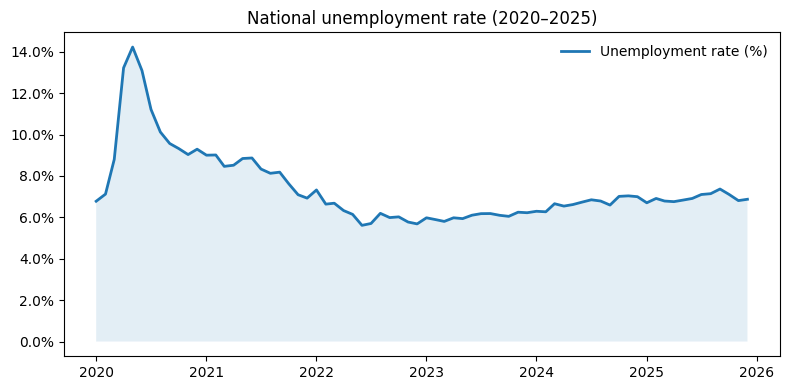

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(national["date"], national["value"], linewidth=2, label="Unemployment rate (%)")
ax.fill_between(national["date"], national["value"],alpha=0.12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax.set_title("National unemployment rate (2020–2025)")
ax.set_xlabel("")
ax.legend(frameon=False)
plt.tight_layout()

The unemployment rate was the highest around 14% during 2021 due to COVID-19. The unemployment rate descreased following next 2 years but there has been an increase in the unemployment rate after 2023.

In [ ]:
emp_level = emp[
    (emp['labour_characteristics'].str.contains('Employment')) &
    (~emp['labour_characteristics'].str.contains('rate', case=False)) &
    (emp['age'].str.contains('15 years and over'))
].copy()

In [ ]:
base_year  = emp_level[emp_level["date"].dt.year == 2020].groupby("province")["value"].mean()
final_year = emp_level[emp_level["date"].dt.year == 2025].groupby("province")["value"].mean()

growth = ((final_year - base_year) / base_year * 100).dropna().sort_values(ascending=True)

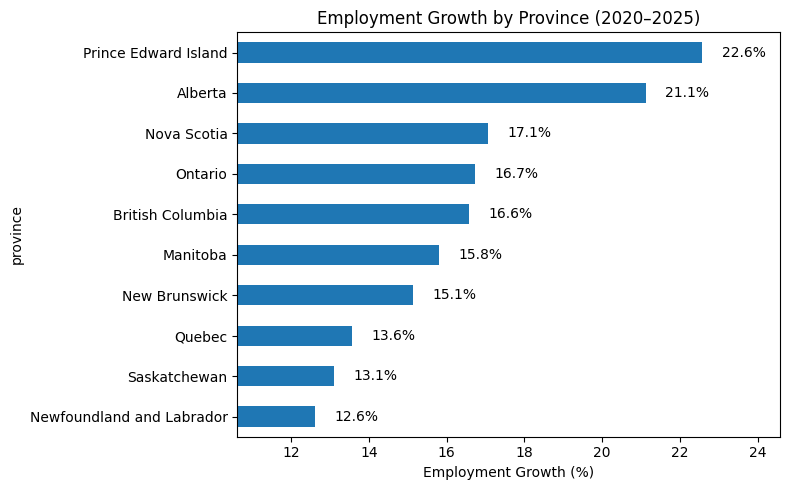

In [ ]:
plt.figure(figsize=(8, 5))
ax = growth.plot(kind='barh')

plt.xlabel('Employment Growth (%)')
plt.title('Employment Growth by Province (2020–2025)')

# Add padding to x-axis
xmin, xmax = growth.min(), growth.max()
plt.xlim(xmin - 2, xmax + 2)

# Add labels safely
for i, v in enumerate(growth):
    offset = 0.5
    if v >= 0:
        ax.text(v + offset, i, f'{v:.1f}%', va='center')
    else:
        ax.text(v - offset, i, f'{v:.1f}%', va='center', ha='right')

plt.axvline(0)
plt.tight_layout()
plt.show()
plt.show()

Prince Edward Island has seen the highest increase in the employment growth over the past 6 years, followed by Alberta.

In [ ]:
new_unemp = emp[
    (emp['labour_characteristics'].str.contains('Unemployment rate')) &
    (emp['age'].str.contains('15 to 24'))
].groupby("date")["value"].mean().reset_index()

exp_unemp = emp[
    (emp['labour_characteristics'].str.contains('Unemployment rate')) &
    (emp['age'].str.contains('25 years and over'))
].groupby("date")["value"].mean().reset_index()

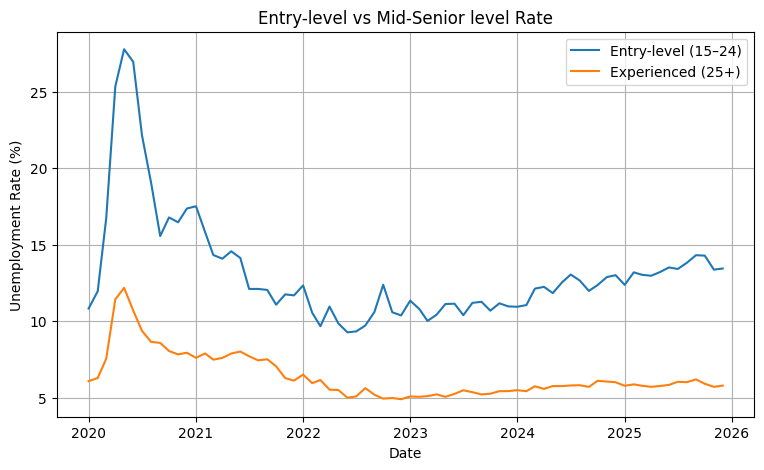

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(new_unemp['date'], new_unemp['value'], label='Entry-level (15–24)')
plt.plot(exp_unemp['date'], exp_unemp['value'], label='Experienced (25+)')

plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.title('Entry-level vs Mid-Senior level Rate')

plt.legend()
plt.grid()

plt.show()

The entry-level positions has higher unemployment rates compared to the experienced professional, with an increase unemployment for new graduates and entry-level professionals from the year 2024.

In [ ]:
def export(emp: pd.DataFrame):

    emp_out = os.path.join(OUTPUT_DIR, "employment_clean.csv")


    emp.to_csv(emp_out, index=False)


    print(f"  {emp_out}  ({len(emp):,} rows)")

    print("\n  These are ready to load into Tableau or SQLite.")

In [ ]:
export(emp)

  outputs/employment_clean.csv  (74,880 rows)

  These are ready to load into Tableau or SQLite.
